# Predicción de admisión según SAT con Regresión Logística y Random Forest

En este notebook vamos a analizar cómo cambia la probabilidad de admisión según el puntaje SAT.
Usaremos dos modelos de clasificación: regresión logística y random forest.

El objetivo es entender el proceso paso a paso y comparar ambos modelos con gráficas importantes.

## 1. Objetivo

Queremos predecir la variable `Admitted` usando solo `SAT`.
Como la respuesta es binaria (`Yes` o `No`), este es un problema de clasificación.

Vamos a responder preguntas como:
- ¿A mayor SAT, aumenta la probabilidad de admisión?
- ¿Qué modelo se adapta mejor a los datos?
- ¿Cómo se ven las curvas de probabilidad y la curva ROC?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Cargar los datos

Primero leemos el archivo `Admittance.csv` y revisamos sus primeras filas para entender su estructura.

In [2]:
df = pd.read_csv('Admittance.csv')

print('Primeras filas del dataset:')
display(df.head())

print('Información general:')
df.info()

print('Valores faltantes:')
print(df.isnull().sum())

Primeras filas del dataset:


,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No


Información general:
<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   SAT       168 non-null    int64
 1   Admitted  168 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.8 KB
Valores faltantes:
SAT         0
Admitted    0
dtype: int64


## 3. Exploración inicial

Aquí verificamos cuántos casos de admisión y no admisión hay, y miramos cómo se distribuyen los puntajes SAT.

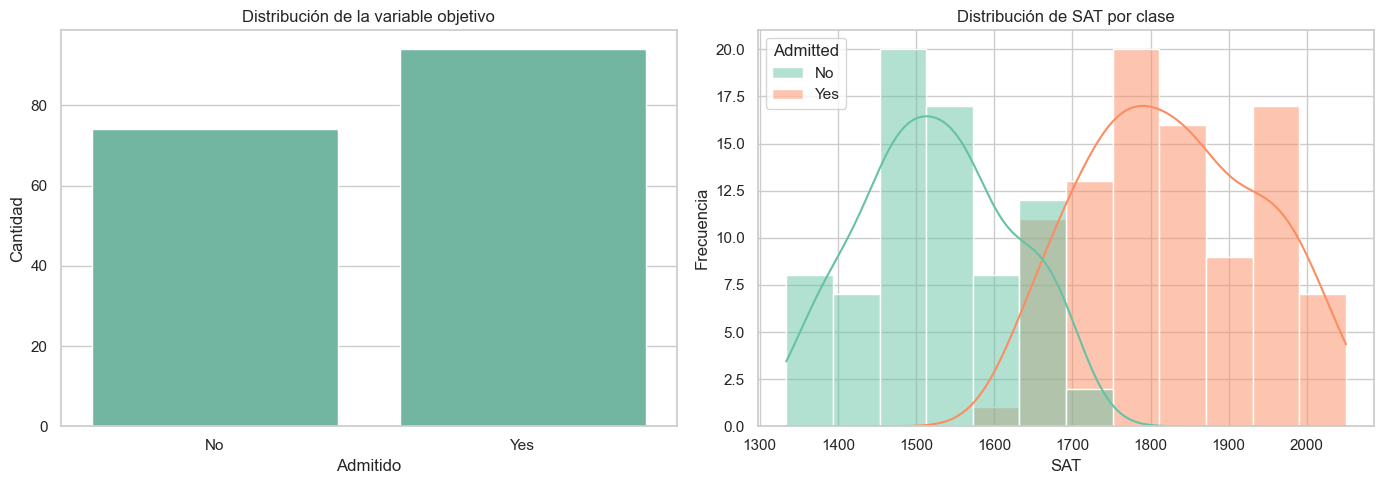

In [3]:
df['Admitted_num'] = df['Admitted'].map({'No': 0, 'Yes': 1})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Admitted', ax=axes[0], color='#66c2a5')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_xlabel('Admitido')
axes[0].set_ylabel('Cantidad')

sns.histplot(data=df, x='SAT', hue='Admitted', kde=True, bins=12, ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de SAT por clase')
axes[1].set_xlabel('SAT')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación de estas gráficas

- El gráfico de barras muestra si hay más casos de `Yes` o `No`.
- El histograma muestra si los valores SAT altos se asocian más con admisión.
- Este paso sirve para entender si el SAT tiene señal suficiente para predecir la admisión.

## 4. Separar variables

Usamos `SAT` como variable explicativa (`X`) y `Admitted_num` como variable objetivo (`y`).

In [4]:
X = df[['SAT']]
y = df['Admitted_num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño de train:', X_train.shape)
print('Tamaño de test:', X_test.shape)

Tamaño de train: (134, 1)
Tamaño de test: (34, 1)


## 5. Modelo 1: Regresión logística

La regresión logística estima una probabilidad entre 0 y 1.
En este caso nos dirá qué tan probable es que un estudiante sea admitido según su SAT.

Estandarizamos el SAT porque este modelo trabaja mejor cuando la escala de la variable está normalizada.

In [5]:
logreg_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

logreg_model.fit(X_train, y_train)
print('Regresión logística entrenada correctamente.')

Regresión logística entrenada correctamente.


## 6. Modelo 2: Random Forest

Random forest combina varios árboles de decisión.
En lugar de una sola regla lineal, puede aprender cortes más flexibles sobre SAT.

Esto puede ayudar si la relación entre SAT y admisión no es perfectamente lineal.

In [6]:
rf_model = Pipeline(steps=[
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
print('Random forest entrenado correctamente.')

Random forest entrenado correctamente.


## 7. Evaluación de los modelos

Vamos a comparar ambos modelos con métricas básicas y matriz de confusión.
Además de accuracy, también veremos recall, porque en problemas de clasificación puede ser importante detectar bien la clase positiva.


=== Regresión logística ===
Accuracy: 0.8824
Recall: 0.8421
ROC AUC: 0.9825

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.82      0.93      0.88        15
         Yes       0.94      0.84      0.89        19

    accuracy                           0.88        34
   macro avg       0.88      0.89      0.88        34
weighted avg       0.89      0.88      0.88        34



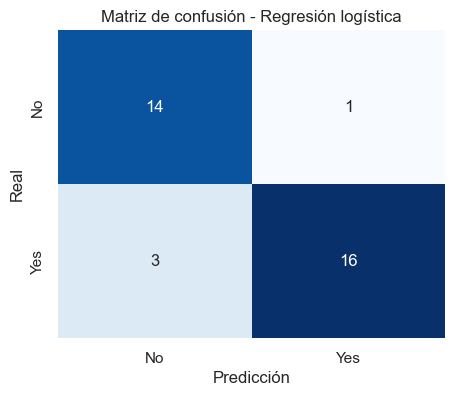


=== Random forest ===
Accuracy: 0.8529
Recall: 0.7895
ROC AUC: 0.9754

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.78      0.93      0.85        15
         Yes       0.94      0.79      0.86        19

    accuracy                           0.85        34
   macro avg       0.86      0.86      0.85        34
weighted avg       0.87      0.85      0.85        34



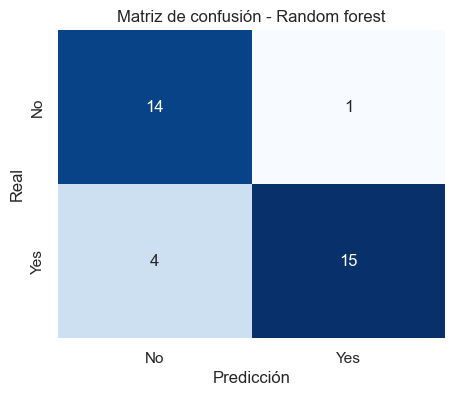

In [7]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc_value = roc_auc_score(y_test, y_prob)

    print(f'\n=== {nombre} ===')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'ROC AUC: {auc_value:.4f}')
    print('\nReporte de clasificación:')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Matriz de confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    return {
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Recall': recall,
        'ROC AUC': auc_value
    }

resultados = []
resultados.append(evaluar_modelo('Regresión logística', logreg_model, X_test, y_test))
resultados.append(evaluar_modelo('Random forest', rf_model, X_test, y_test))

### Comparación visual de métricas

Esta gráfica ayuda a ver rápidamente qué modelo obtuvo mejores valores de accuracy, recall y AUC.

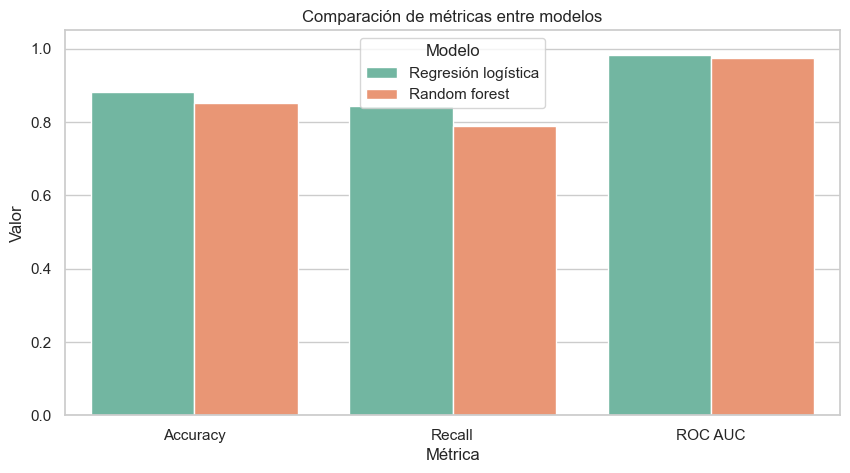

,Modelo,Accuracy,Recall,ROC AUC
0,Regresión logística,0.882353,0.842105,0.982456
1,Random forest,0.852941,0.789474,0.975439


In [8]:
resultados_df = pd.DataFrame(resultados)
resultados_melt = resultados_df.melt(id_vars='Modelo', var_name='Metrica', value_name='Valor')

plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_melt, x='Metrica', y='Valor', hue='Modelo', palette='Set2')
plt.ylim(0, 1.05)
plt.title('Comparación de métricas entre modelos')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.legend(title='Modelo')
plt.show()

display(resultados_df)

## 8. Curvas de probabilidad

Ahora graficamos la probabilidad estimada de admisión para distintos valores de SAT.
Esta es una de las gráficas más importantes del notebook porque muestra cómo piensa cada modelo.

- La línea de regresión logística es suave.
- La línea de random forest suele ser más escalonada o irregular.
- Los puntos muestran los datos reales.

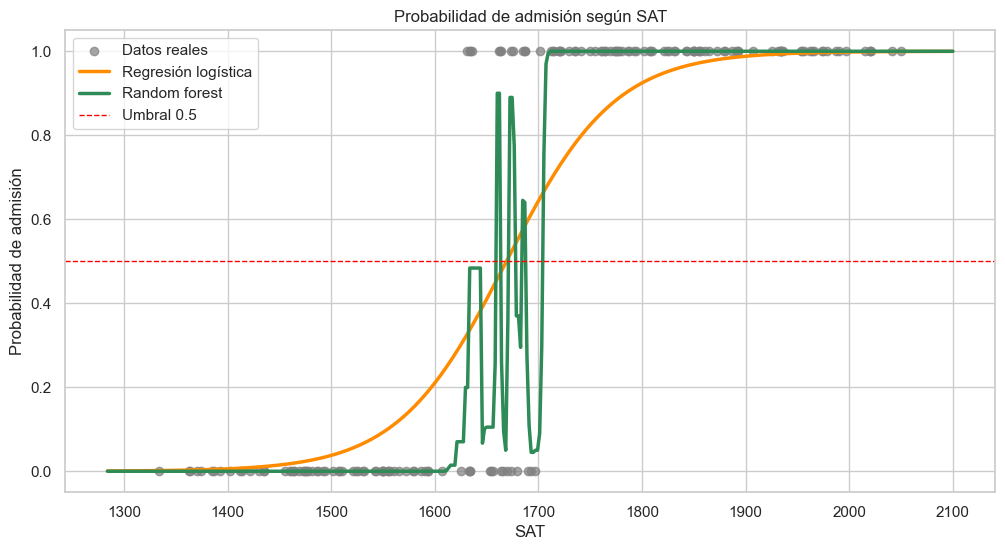

In [9]:
sat_grid = np.linspace(df['SAT'].min() - 50, df['SAT'].max() + 50, 400).reshape(-1, 1)
sat_grid_df = pd.DataFrame({'SAT': sat_grid.ravel()})
logreg_prob = logreg_model.predict_proba(sat_grid_df)[:, 1]
rf_prob = rf_model.predict_proba(sat_grid_df)[:, 1]

plt.figure(figsize=(12, 6))
plt.scatter(df['SAT'], df['Admitted_num'], alpha=0.7, color='gray', label='Datos reales')
plt.plot(sat_grid, logreg_prob, color='darkorange', lw=2.5, label='Regresión logística')
plt.plot(sat_grid, rf_prob, color='seagreen', lw=2.5, label='Random forest')
plt.axhline(0.5, color='red', linestyle='--', lw=1, label='Umbral 0.5')
plt.xlabel('SAT')
plt.ylabel('Probabilidad de admisión')
plt.title('Probabilidad de admisión según SAT')
plt.legend()
plt.show()

## 9. Curva ROC

La curva ROC compara la tasa de verdaderos positivos contra la tasa de falsos positivos.
Mientras más cerca esté la curva de la esquina superior izquierda, mejor separa el modelo las clases.

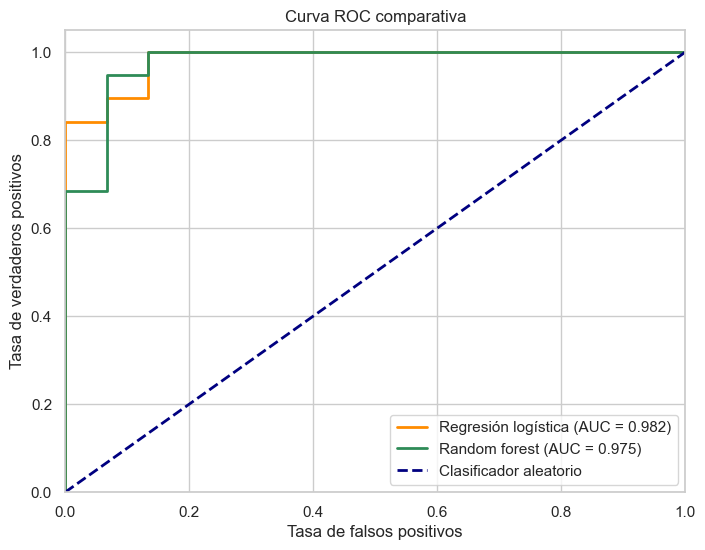

In [10]:
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, color='darkorange', lw=2, label=f'Regresión logística (AUC = {auc_logreg:.3f})')
plt.plot(fpr_rf, tpr_rf, color='seagreen', lw=2, label=f'Random forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC comparativa')
plt.legend(loc='lower right')
plt.show()

## 10. Conclusión

Con este análisis podemos ver dos formas distintas de modelar la relación entre SAT y admisión.

- La regresión logística es más interpretable y genera una curva suave de probabilidad.
- Random forest puede capturar patrones más flexibles, aunque con una sola variable a veces no aporta una ventaja grande.
- La curva ROC y el AUC ayudan a comparar ambos modelos sin depender solo de una predicción puntual.

Si quieres seguir explorando, el siguiente paso natural sería probar más variables explicativas además del SAT.